# S1. Window size and rasterisation resolution

Supplementary experiment. Which **field of view** should a window cover, and how
finely should it be **rasterised**? Both are answered on JHH369 alone (4 ROIs,
30,704 cells, each 1100 × 1100 µm).

## Design

Window FOV = `pixel_size × global_size`, so the two knobs are not independent —
sweeping one without pinning the other confounds *scale* with *resolution*. The four
configs form an **L**, sharing the production config as its hinge:

| | FOV | pixel_size | global / local |
|---|---|---|---|
| **A** | 128 µm | 2.0 | 64 / 48 |
| **B** | 192 µm | 2.0 | 96 / 64 | ← production config |
| **C** | 192 µm | 3.0 | 64 / 48 |
| **D** | 192 µm | 1.5 | 128 / 80 |
| **E** | 64 µm | 2.0 | 32 / 24 |
| **F** | 96 µm | 2.0 | 48 / 32 |

Three comparisons fall out:

- **A vs B** — FOV 128 vs 192 at fixed resolution. *How much tissue?*
- **C vs B vs D** — FOV pinned at 192, resolution 3.0 / 2.0 / 1.5 µm/px. *How finely rasterised?*
- **A vs C** — identical network input (64/48), identical compute, differing **only** in
  physical scale. Isolates FOV from model capacity.

Training is a **comparative screen**: 200 epochs × 6,400 steps each, an identical
schedule for all four, so the *ranking* is fair even though no single model is
converged. Run `python tissuemosaic/run_window_sweep.py` first (~13.2 h).

## Setup

In [1]:
%matplotlib inline
import sys
from pathlib import Path
# resolve imc_tm from anywhere: repo root, tissuemosaic/, notebooks/, notebooks/archive/
_cands = [c for p in [Path.cwd(), *Path.cwd().parents] for c in (p, p / "tissuemosaic")]
sys.path.insert(0, str(next(c for c in _cands if (c / "imc_tm.py").exists())))
import imc_tm

import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import seaborn
import warnings; warnings.filterwarnings("ignore")

print("repo:", imc_tm.REPO)
print(imc_tm.compat_summary())

repo: /home/gavehan/PDACAntigenPresentationABMs
tm_compat: 34 numpy types allowlisted (weights_only stays True); relaxed only for test_dataset.pt, train_dataset.pt


### Is the sweep trained?

In [2]:
status = imc_tm.sweep_status()
READY = bool(status.trained.all())
print(status.to_string(index=False))
print()
if READY:
    print("All six configs trained -- proceeding.")
else:
    missing = list(status.loc[~status.trained, "name"])
    print("NOT READY. Missing checkpoints for:", ", ".join(missing))
    print()
    print("Train them first (~13.2 h):")
    print("    python tissuemosaic/run_window_sweep.py")
    print()
    print("The analysis cells below will skip until then.")

          name  fov_um  pixel_size  global_size  local_size  trained  ckpt_MB  periodic_ckpts
A_fov128_px2.0     128         2.0           64          48     True      349               8
B_fov192_px2.0     192         2.0           96          64     True      349               8
C_fov192_px3.0     192         3.0           64          48     True      349               8
D_fov192_px1.5     192         1.5          128          80     True      349               8
 E_fov64_px2.0      64         2.0           32          24     True      349               8
 F_fov96_px2.0      96         2.0           48          32     True      349               8

All six configs trained -- proceeding.


### The configs, and what each costs

`global_size` and `local_size` are multiples of 16 so the backbone's 16× downsampling
gives clean pre-pool feature maps (64→4×4, 96→6×6, 128→8×8).

In [3]:
rows = []
for spec in imc_tm.WINDOW_SWEEP:
    cfg = imc_tm.sweep_config_dict(spec)
    fov = cfg["pixel_size"] * cfg["global_size"]
    # Window count follows the RASTER size, not the ROI extent: SparseImage pads
    # by 10 px a side. ~1100 um / pixel_size + 20, tiled by global_size.
    raster_px = 1100 / cfg["pixel_size"] + 20
    per_roi = int((raster_px // cfg["global_size"]) ** 2)
    rows.append({
        "name": spec["name"], "FOV_um": fov, "pixel_size": cfg["pixel_size"],
        "global": cfg["global_size"], "local": cfg["local_size"],
        "prepool_map": f"{cfg['global_size']//16}x{cfg['global_size']//16}",
        "cells_per_window": round(6348 * (fov / 1000) ** 2),
        "raster_px": int(raster_px), "est_windows_per_ROI": per_roi,
        "epochs": cfg["max_epochs"], "warm_up/down": f"{cfg['warm_up_epochs']}/{cfg['warm_down_epochs']}",
    })
print("est_windows_per_ROI is a floor estimate -- the cropper drops tiles with too few")
print("cells and can fit a partial extra row, so actual counts run somewhat higher.")
print("Actual counts are reported after featurisation below.")
pd.DataFrame(rows)

est_windows_per_ROI is a floor estimate -- the cropper drops tiles with too few
cells and can fit a partial extra row, so actual counts run somewhat higher.
Actual counts are reported after featurisation below.


,name,FOV_um,pixel_size,global,local,prepool_map,cells_per_window,raster_px,est_windows_per_ROI,epochs,warm_up/down
0,A_fov128_px2.0,128.0,2.0,64,48,4x4,104,570,64,200,20/100
1,B_fov192_px2.0,192.0,2.0,96,64,6x6,234,570,25,200,20/100
2,C_fov192_px3.0,192.0,3.0,64,48,4x4,234,386,36,200,20/100
3,D_fov192_px1.5,192.0,1.5,128,80,8x8,234,753,25,200,20/100
4,E_fov64_px2.0,64.0,2.0,32,24,2x2,26,570,289,200,20/100
5,F_fov96_px2.0,96.0,2.0,48,32,3x3,59,570,121,200,20/100


## Featurise every window

Tiling, **not** random sampling: each window keeps a known position, which the
spatial-coherence metric needs. `frac_overlap = 0.0` because overlapping windows
share cells, which would inflate that metric.

Window count is set by **FOV**, not resolution: B, C and D all cover 192 µm, so they
tile into a similar number of windows despite very different rasters, while A at
128 µm yields roughly 2× more. That asymmetry is inherent to fixed-size ROIs — which
is exactly why every metric below is reported against a permutation null rather than
as a raw value.

In [4]:
adatas = {r: a for r, a in imc_tm.load_all_anndata().items() if r.startswith(imc_tm.SWEEP_PATIENT)}
print(f"{len(adatas)} ROIs: {', '.join(sorted(adatas))}")

FRAC_OVERLAP = 0.0
# Analysis filter SCALES with FOV -- see imc_tm.fov_scaled_threshold.
# A fixed value is itself FOV-dependent: 50 cells is 48% of an expected 128 um
# window but only 21% of a 192 um one, so round 1 stripped borders at 128 um and
# none at 192 um (retained border share 32% vs 51%).
FILTER_FRACTION = 0.5   # threshold = 0.5 x expected cells for that FOV
SEED = 0          # pins the random tiling origin AND Leiden; see S1a for why this matters
results = {}
if READY:
    for spec in imc_tm.WINDOW_SWEEP:
        name = spec["name"]
        print(f"\n=== {name}  (FOV {spec['fov_um']} um, {spec['pixel_size']} um/px) ===")
        cfg = imc_tm.sweep_config_dict(spec)
        thr = imc_tm.fov_scaled_threshold(spec["fov_um"], fraction=FILTER_FRACTION)
        cfg["n_element_min_for_crop"] = thr   # ANALYSIS filter, not the training value
        model = imc_tm.load_model(imc_tm.sweep_checkpoint(name))
        dm = imc_tm.make_datamodule(cfg)
        results[name] = imc_tm.featurize_windows(model, dm, adatas, frac_overlap=FRAC_OVERLAP, seed=SEED)
        print("  total windows:", len(results[name]["roi"]),
              "| feature dim:", results[name]["features"].shape[1])
        del model, dm
else:
    print("skipped -- sweep not trained")

4 ROIs: JHH369ROI1, JHH369ROI2, JHH369ROI3, JHH369ROI4

=== A_fov128_px2.0  (FOV 128 um, 2.0 um/px) ===


[neptune] [warning] NeptuneDeprecationWarning: The 'neptune-client' package has been deprecated and will be removed in the future. Install the 'neptune' package instead. For more, see https://docs-legacy.neptune.ai/setup/upgrading/
[neptune] [warning] NeptuneDeprecationWarning: You're importing the Neptune client library via the deprecated `neptune.new` module, which will be removed in a future release. Import directly from `neptune` instead.


/home/gavehan/miniforge3/envs/tissue-mosaic-260819/lib/python3.10/site-packages/pl_bolts/models/self_supervised/amdim/amdim_module.py:34: UnderReviewWarning: The feature generate_power_seq is currently marked under review. The compatibility with other Lightning projects is not guaranteed and API may change at any time. The API and functionality may change without warning in future releases. More details: https://lightning-bolts.readthedocs.io/en/latest/stability.html
  "lr_options": generate_power_seq(LEARNING_RATE_CIFAR, 11),
/home/gavehan/miniforge3/envs/tissue-mosaic-260819/lib/python3.10/site-packages/pl_bolts/models/self_supervised/amdim/amdim_module.py:92: UnderReviewWarning: The feature FeatureMapContrastiveTask is currently marked under review. The compatibility with other Lightning projects is not guaranteed and API may change at any time. The API and functionality may change without warning in future releases. More details: https://lightning-bolts.readthedocs.io/en/latest/sta

number of elements ---> 8025
mean and median spacing 7.24660801409835, 6.800890061414151
The dense shape of the image is -> torch.Size([10, 581, 581])


  JHH369ROI1       73 windows
number of elements ---> 6383
mean and median spacing 7.260443804123195, 6.5180040620742385
The dense shape of the image is -> torch.Size([10, 580, 580])


...

number of elements ---> 8025
mean and median spacing 7.24660801409835, 6.800890061414151
The dense shape of the image is -> torch.Size([10, 581, 581])


  JHH369ROI1      129 windows
number of elements ---> 6383
mean and median spacing 7.260443804123195, 6.5180040620742385
The dense shape of the image is -> torch.Size([10, 580, 580])


  JHH369ROI2      119 windows
number of elements ---> 7572
mean and median spacing 6.975763445255431, 6.472262341392154
The dense shape of the image is -> torch.Size([10, 581, 581])


  JHH369ROI3      118 windows
number of elements ---> 8724
mean and median spacing 6.807801972872951, 6.434931372051974
The dense shape of the image is -> torch.Size([10, 580, 581])


  JHH369ROI4      133 windows
  total windows: 499 | feature dim: 512


## Cluster the windows

PCA → kNN graph → Leiden → UMAP, identical hyperparameters for every config so the
comparison is not confounded by clustering settings.

In [5]:
RESOLUTION, N_NEIGHBORS = 1.0, 15   # SEED set above, shared with featurisation
clusters = {}
for name, res in results.items():
    clusters[name] = imc_tm.cluster_embedding(res["features"], n_neighbors=N_NEIGHBORS,
                                              resolution=RESOLUTION, seed=SEED)
    print(f"{name:<16s} {len(res['roi']):4d} windows -> "
          f"{len(np.unique(clusters[name]['labels'])):2d} clusters")
if not results:
    print("skipped -- sweep not trained")

A_fov128_px2.0    272 windows -> 11 clusters
B_fov192_px2.0    123 windows ->  9 clusters


C_fov192_px3.0    118 windows ->  8 clusters
D_fov192_px1.5    124 windows ->  6 clusters


E_fov64_px2.0    1078 windows -> 15 clusters


F_fov96_px2.0     499 windows -> 12 clusters


## Comparison metrics

| metric | what it asks | good |
|---|---|---|
| `coherence_kappa` | do neighbouring windows share a cluster more than chance? | **high** |
| `spatial_coherence_z` | is that above chance at all? | significance only |
| `roi_mixing` | do clusters span ROIs, or just recover ROI identity? | read vs baseline |
| `composition_silhouette` | how much of the embedding is explained by **bulk composition alone** | context, not "high" |
| `n_clusters` | how much structure the representation supports | context |

**Rank on `coherence_kappa`, not on the z-score.** Both compare the observed
neighbour agreement to a within-ROI label permutation, but they standardise it
differently:

- `coherence_kappa` = (obs − null) / (1 − null) — the share of the available
  headroom above chance that the clustering captures. A probability difference,
  so it does not grow with the number of windows.
- `spatial_coherence_z` = (obs − null) / null_sd — and null_sd shrinks as
  ~1/√n_pairs, so **z grows as ~√N at a fixed effect size**.

That matters here because the FOV-scaled filter equalises *coverage*, not *count*:
the six configs retain 118–1078 windows, a 9× spread and therefore a 3× swing in z
from arithmetic alone. Ranking on z would hand the win to the smallest FOV
automatically. The round-1 A-vs-B call (z 23.5 vs 12.2 at N 272 vs 123) carried
roughly 1.5× of its gap from N for the same reason.

`roi_mixing` is **not** simply "higher is better", despite the arrow above. Cell-type
proportions recur across ROIs trivially, so clustering the raw composition vector with
no model scores high by default — read the value against *that* baseline:

| | model embedding | composition baseline |
|---|---|---|
| A 128 µm | 0.650 | 0.837 |
| E 64 µm | 0.898 | 0.906 |

E looks like the winner and is not: its 0.898 sits *on* its own baseline, meaning the
embedding added nothing beyond composition — and E's model buys only +23% spatial
coherence over that baseline against A's +203%. A's 0.650 is far *below* its baseline,
so A's clusters carry something composition does not. What a low value cannot
distinguish is real per-ROI architecture from batch; that needs the full cohort.

It still matters most at large FOV, where each 192 µm window covers ~3% of its ROI.

`composition_silhouette` is **not** "higher is better". A model that merely bins
windows by cell-type proportions scores high; one that keys on spatial *arrangement*
— the whole point of TissueMosaic over a neighbourhood-composition vector — scores
lower while still scoring high on coherence. Config A came in at -0.08 while reaching
a coherence z of 16.8 and recovering the ROI3 CD8 infiltrate and the ROI1 apCAF
cluster from notebook 0. Read it as *how composition-like is this embedding*, and
weigh it against coherence rather than maximising it.

In [6]:
if results:
    met = pd.DataFrame([
        {"name": n, "FOV_um": imc_tm.sweep_spec(n)["fov_um"],
         "pixel_size": imc_tm.sweep_spec(n)["pixel_size"],
         **imc_tm.window_metrics(results[n], clusters[n]["labels"], k=4, n_perm=200, seed=SEED)}
        for n in results
    ]).set_index("name")
    display(met.style.format(precision=3))
else:
    met = None
    print("skipped -- sweep not trained")

,FOV_um,pixel_size,n_windows,n_clusters,spatial_coherence,coherence_kappa,spatial_coherence_z,roi_mixing,roi_mixing_null,composition_silhouette
name,,,,,,,,,,
A_fov128_px2.0,128,2.000,272,11,0.528,0.415,23.509,0.650,0.956,-0.028
B_fov192_px2.0,192,2.000,123,9,0.461,0.333,13.240,0.672,0.920,-0.074
C_fov192_px3.0,192,3.000,118,8,0.394,0.251,8.932,0.773,0.925,-0.110
D_fov192_px1.5,192,1.500,124,6,0.460,0.309,10.763,0.825,0.950,-0.016
E_fov64_px2.0,64,2.000,1078,15,0.179,0.096,14.713,0.898,0.985,-0.087
F_fov96_px2.0,96,2.000,499,12,0.258,0.155,13.661,0.846,0.975,-0.032


### Correcting kappa for grid geometry

kappa removes the z-score's √N inflation, but not every geometry effect, and the
residual is **large**. `imc_tm.coherence_ceiling` measures it directly: lay down
synthetic tissue domains of a fixed physical size, label each window by the domain
its centre falls in, and score that ground truth. Since it *is* ground truth, its
kappa is the best any model could do on that grid.

At 250 µm domains a perfect model scores **3.9× higher at 64 µm than at 192 µm** —
a 192 µm window is roughly one whole domain, so neighbouring windows rarely share
one, while sixteen 64 µm windows tile the same domain. So raw kappa is not
comparable across FOV either; `kappa_norm = kappa / ceiling` is.

The true domain size is unknown, so this reports several and **the check that
matters is whether the ranking is stable across them**. JHH369 is coarser than
250 µm: config A's observed kappa already exceeds its own D250 ceiling.

In [7]:
DOMAINS = [250.0, 400.0, 600.0, 800.0]
if met is not None:
    norm = met[["FOV_um", "n_windows", "coherence_kappa"]].copy()
    for D in DOMAINS:
        ceil = {n: imc_tm.coherence_ceiling(results[n]["centers_um"], results[n]["roi"], D)
                for n in met.index}
        norm[f"ceil{D:.0f}"] = [ceil[n] for n in norm.index]
        norm[f"norm{D:.0f}"] = norm["coherence_kappa"] / norm[f"ceil{D:.0f}"]
    display(norm.style.format(precision=3))

    rank_cols = [f"norm{D:.0f}" for D in DOMAINS]
    print()
    print("ranking by kappa_norm at each domain size (best first):")
    for c in rank_cols:
        print(f"  {c:9s} " + " > ".join(norm[c].sort_values(ascending=False).index))
    agree = len({tuple(norm[c].sort_values(ascending=False).index) for c in rank_cols}) == 1
    print()
    print("ranking stable across domain sizes:", agree)
    if not agree:
        print("  -> the FOV verdict depends on assumed domain size; report the range, not a winner")
else:
    norm = None
    print("skipped -- sweep not trained")

,FOV_um,n_windows,coherence_kappa,ceil250,norm250,ceil400,norm400,ceil600,norm600,ceil800,norm800
name,,,,,,,,,,,
A_fov128_px2.0,128,272,0.415,0.371,1.118,0.536,0.774,0.652,0.636,0.679,0.611
B_fov192_px2.0,192,123,0.333,0.172,1.943,0.345,0.965,0.489,0.682,0.548,0.608
C_fov192_px3.0,192,118,0.251,0.177,1.418,0.345,0.728,0.490,0.513,0.531,0.473
D_fov192_px1.5,192,124,0.309,0.174,1.769,0.348,0.886,0.502,0.615,0.556,0.555
E_fov64_px2.0,64,1078,0.096,0.663,0.144,0.759,0.126,0.825,0.116,0.840,0.114
F_fov96_px2.0,96,499,0.155,0.513,0.301,0.642,0.241,0.742,0.208,0.762,0.203



ranking by kappa_norm at each domain size (best first):
  norm250   B_fov192_px2.0 > D_fov192_px1.5 > C_fov192_px3.0 > A_fov128_px2.0 > F_fov96_px2.0 > E_fov64_px2.0
  norm400   B_fov192_px2.0 > D_fov192_px1.5 > A_fov128_px2.0 > C_fov192_px3.0 > F_fov96_px2.0 > E_fov64_px2.0
  norm600   B_fov192_px2.0 > A_fov128_px2.0 > D_fov192_px1.5 > C_fov192_px3.0 > F_fov96_px2.0 > E_fov64_px2.0
  norm800   A_fov128_px2.0 > B_fov192_px2.0 > D_fov192_px1.5 > C_fov192_px3.0 > F_fov96_px2.0 > E_fov64_px2.0

ranking stable across domain sizes: False
  -> the FOV verdict depends on assumed domain size; report the range, not a winner


### The four comparisons, read off directly

In [8]:
if met is not None:
    def show(title, names, question):
        print(f"\n{title}\n  {question}")
        sub = met.loc[[n for n in names if n in met.index],
                      ["FOV_um", "pixel_size", "n_windows", "n_clusters",
                       "coherence_kappa", "spatial_coherence_z",
                       "roi_mixing", "composition_silhouette"]]
        print(sub.to_string(float_format=lambda v: f"{v:.3f}"))

    show("E vs F vs A vs B  -- the FOV series, resolution fixed at 2.0 um/px",
         ["E_fov64_px2.0", "F_fov96_px2.0", "A_fov128_px2.0", "B_fov192_px2.0"],
         "How much tissue should a window cover? 64 -> 192 um, a 3x range.")
    show("C vs B vs D  -- resolution, FOV fixed at 192 um",
         ["C_fov192_px3.0", "B_fov192_px2.0", "D_fov192_px1.5"], "How finely should it be rasterised?")
    show("A vs C  -- FOV at IDENTICAL network input (64/48)",
         ["A_fov128_px2.0", "C_fov192_px3.0"], "Does scale matter independently of compute?")
    show("E vs A  -- IDENTICAL FOV ratio to A vs B, at the small end",
         ["E_fov64_px2.0", "A_fov128_px2.0"], "Is the FOV response monotone, or does it turn?")


E vs F vs A vs B  -- the FOV series, resolution fixed at 2.0 um/px
  How much tissue should a window cover? 64 -> 192 um, a 3x range.
                FOV_um  pixel_size  n_windows  n_clusters  coherence_kappa  spatial_coherence_z  roi_mixing  composition_silhouette
name                                                                                                                               
E_fov64_px2.0       64       2.000       1078          15            0.096               14.713       0.898                  -0.087
F_fov96_px2.0       96       2.000        499          12            0.155               13.661       0.846                  -0.032
A_fov128_px2.0     128       2.000        272          11            0.415               23.509       0.650                  -0.028
B_fov192_px2.0     192       2.000        123           9            0.333               13.240       0.672                  -0.074

C vs B vs D  -- resolution, FOV fixed at 192 um
  How finely should it b

## The tiebreaker: what did the model add over a count vector?

The ceiling-normalised ranking above is **unstable across assumed domain size**, because
it divides by a ceiling that differs ~2× between configs and so amplifies small absolute
differences at large FOV. This test does not have that problem.

Cluster the raw biology-composition vector — an 8-number summary, no network — on the
**same window grid** as the model, and take the ratio. Both terms face identical
geometry, so the geometric advantage cancels exactly, and no assumption about domain
size enters.

It also asks the question that actually matters. TissueMosaic's claim over a
neighbourhood-composition vector is that it encodes spatial *arrangement*. A config
whose embedding clusters are no more spatially coherent than composition clusters has
added nothing you could not compute in a spreadsheet.

In [9]:
BIO_IDX = [imc_tm.CELL_TYPES.index(t) for t in imc_tm.BIOLOGY_TYPES]
def bio_frac(comp):
    b = np.asarray(comp)[:, BIO_IDX]
    return b / np.clip(b.sum(axis=1, keepdims=True), 1e-9, None)

if results:
    rows = []
    for n in results:
        lab_c = imc_tm.cluster_embedding(bio_frac(results[n]["composition"]),
                                         n_neighbors=N_NEIGHBORS, resolution=RESOLUTION,
                                         seed=SEED)["labels"]
        mm = met.loc[n]
        mc = imc_tm.window_metrics(results[n], lab_c, k=4, n_perm=200, seed=SEED)
        rows.append({"name": n, "FOV_um": imc_tm.sweep_spec(n)["fov_um"],
                     "kappa_model": mm["coherence_kappa"], "kappa_comp": mc["coherence_kappa"],
                     "gain_x": mm["coherence_kappa"] / max(mc["coherence_kappa"], 1e-9),
                     "roimix_model": mm["roi_mixing"], "roimix_comp": mc["roi_mixing"]})
    gain = pd.DataFrame(rows).set_index("name").sort_values("gain_x", ascending=False)
    display(gain.style.format(precision=3))

    print("ranked by gain over the composition baseline (geometry cancels):")
    for i, (n, v) in enumerate(gain["gain_x"].items(), 1):
        print(f"  {i}. {n:<16s} {v:.2f}x")
    print()
    print("roi_mixing is only meaningful against its own baseline -- a value sitting ON")
    print("the baseline means the embedding added nothing, not that it found shared motifs:")
    for n, r in gain.iterrows():
        print(f"  {n:<16s} {r['roimix_model']:.3f} vs baseline {r['roimix_comp']:.3f}  "
              f"(departure {r['roimix_model'] - r['roimix_comp']:+.3f})")
else:
    gain = None
    print("skipped -- sweep not trained")

,FOV_um,kappa_model,kappa_comp,gain_x,roimix_model,roimix_comp
name,,,,,,
A_fov128_px2.0,128,0.415,0.137,3.033,0.650,0.837
B_fov192_px2.0,192,0.333,0.173,1.926,0.672,0.833
D_fov192_px1.5,192,0.309,0.169,1.830,0.825,0.806
C_fov192_px3.0,192,0.251,0.167,1.508,0.773,0.813
E_fov64_px2.0,64,0.096,0.078,1.230,0.898,0.906
F_fov96_px2.0,96,0.155,0.126,1.225,0.846,0.894


ranked by gain over the composition baseline (geometry cancels):
  1. A_fov128_px2.0   3.03x
  2. B_fov192_px2.0   1.93x
  3. D_fov192_px1.5   1.83x
  4. C_fov192_px3.0   1.51x
  5. E_fov64_px2.0    1.23x
  6. F_fov96_px2.0    1.23x

roi_mixing is only meaningful against its own baseline -- a value sitting ON
the baseline means the embedding added nothing, not that it found shared motifs:
  A_fov128_px2.0   0.650 vs baseline 0.837  (departure -0.187)
  B_fov192_px2.0   0.672 vs baseline 0.833  (departure -0.161)
  D_fov192_px1.5   0.825 vs baseline 0.806  (departure +0.019)
  C_fov192_px3.0   0.773 vs baseline 0.813  (departure -0.041)
  E_fov64_px2.0    0.898 vs baseline 0.906  (departure -0.009)
  F_fov96_px2.0    0.846 vs baseline 0.894  (departure -0.048)


## UMAPs

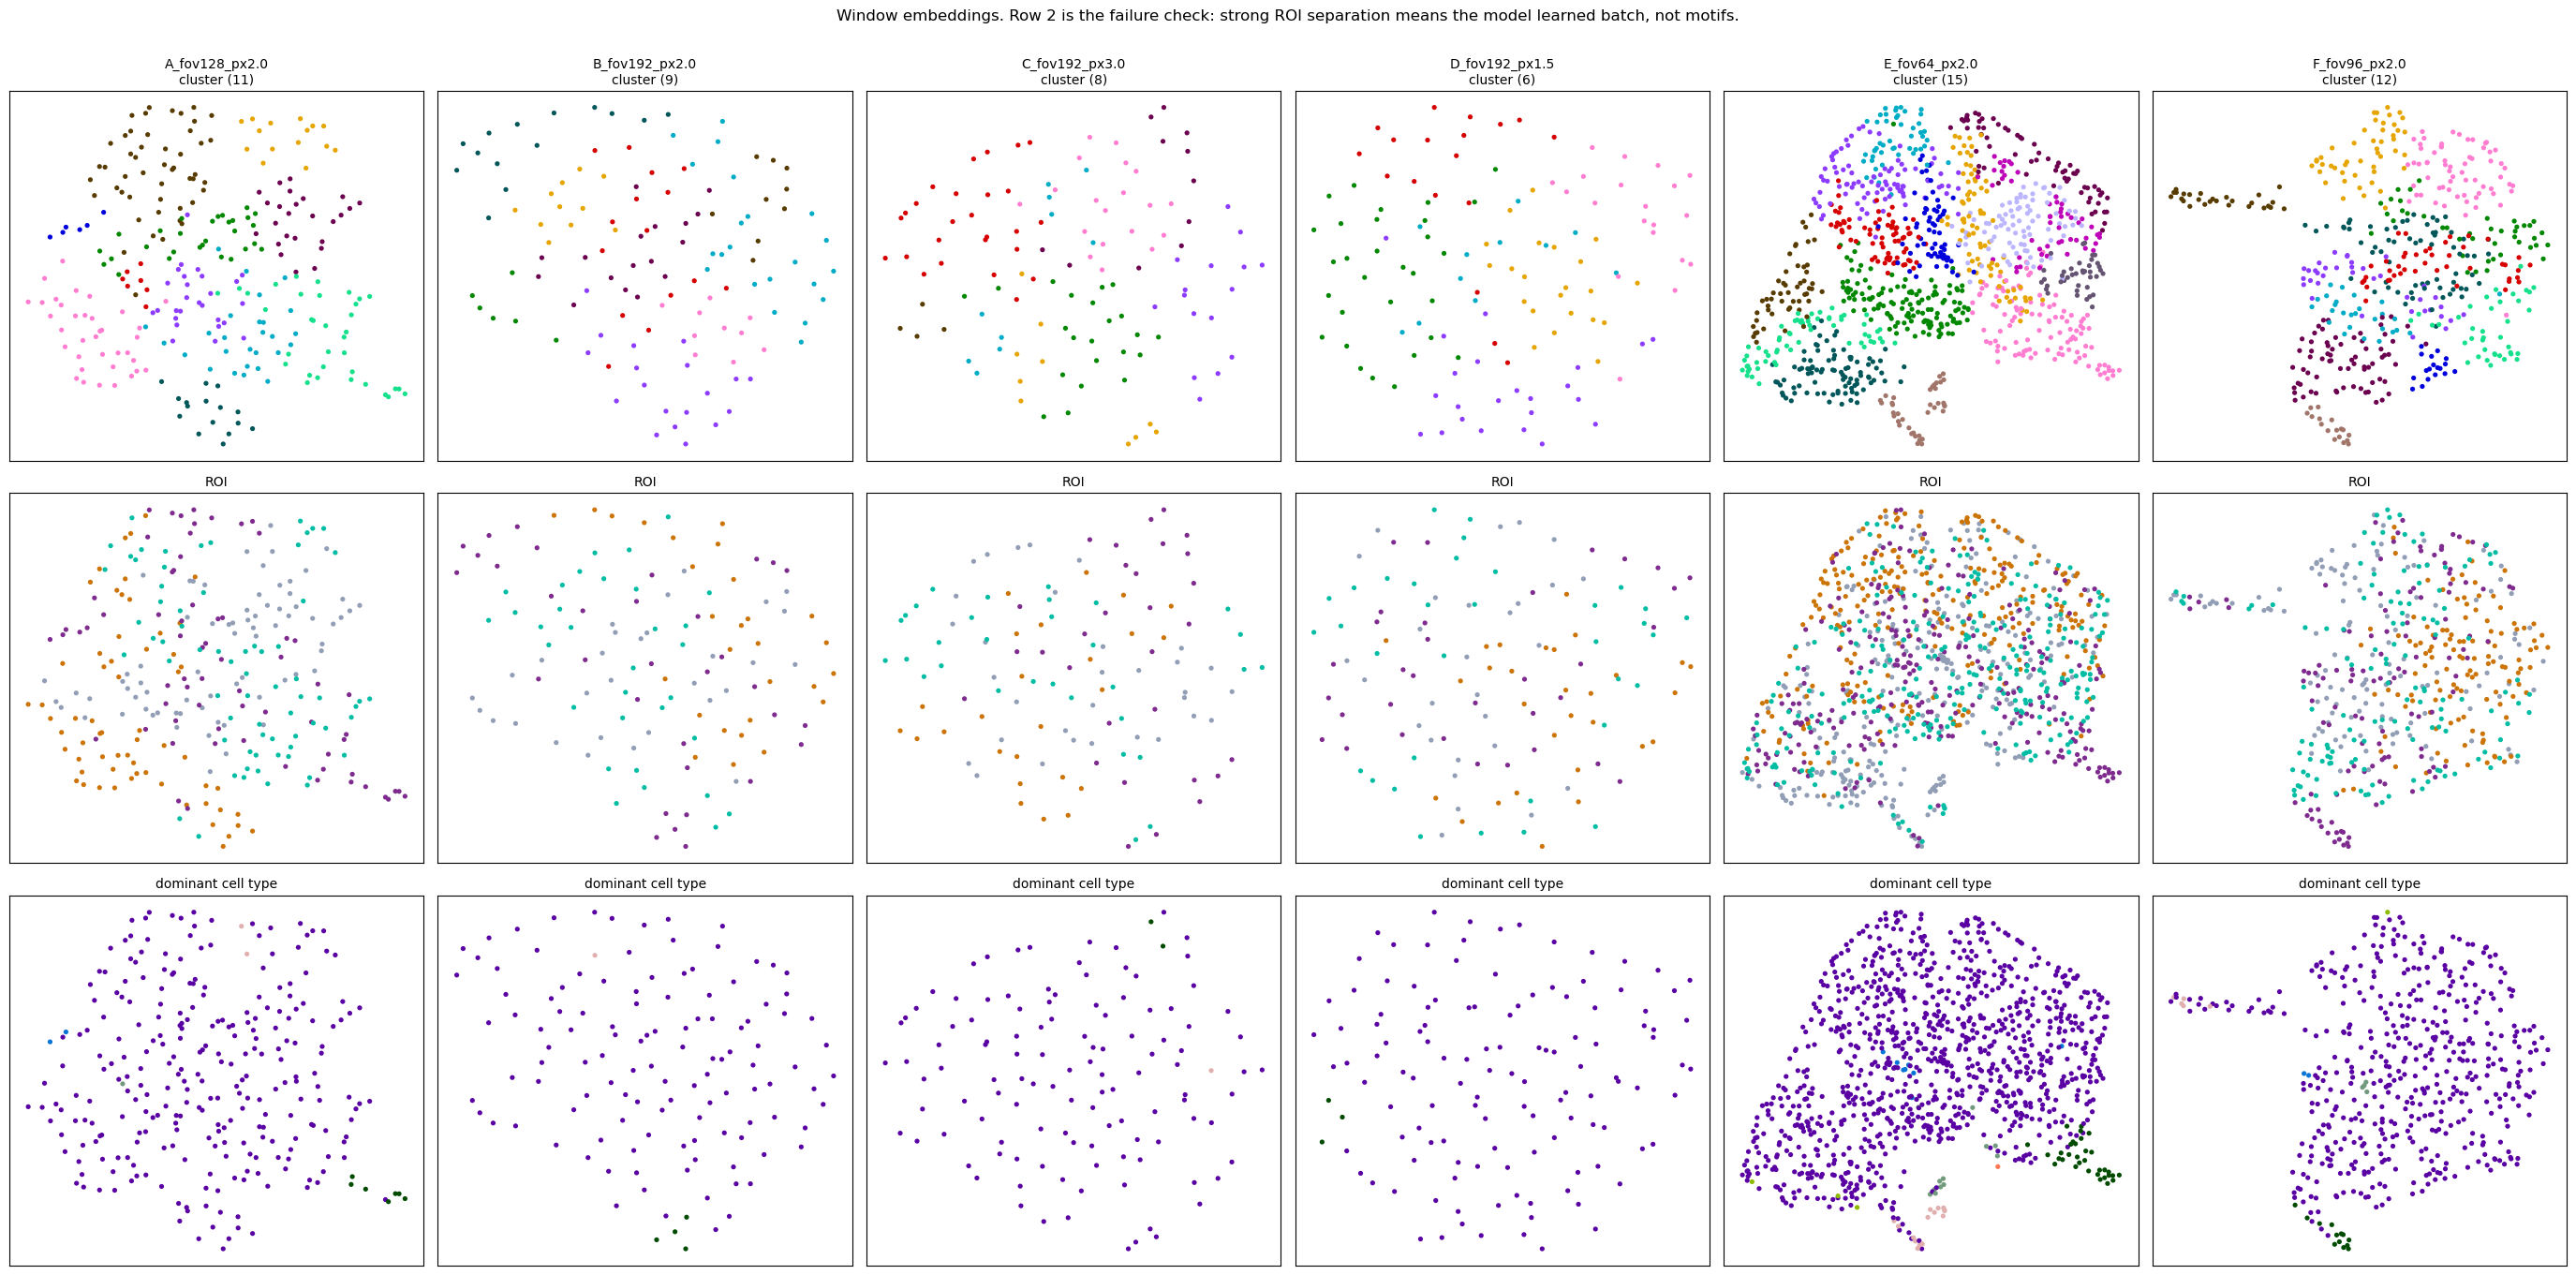

In [10]:
if results:
    n = len(results)
    fig, axes = plt.subplots(3, n, figsize=(4.6 * n, 13.5))
    axes = np.atleast_2d(axes)
    # every categorical family from glasbey_dark, each on its own slice -- see
    # imc_tm.GLASBEY_OFFSET
    rc = imc_tm.roi_palette(sorted(adatas))
    ctp = imc_tm.palette()
    for j, name in enumerate(results):
        u, lab, res = clusters[name]["umap"], clusters[name]["labels"], results[name]
        cc = imc_tm.cluster_palette(labels=sorted(np.unique(lab)))
        axes[0, j].scatter(u[:, 0], u[:, 1], c=[cc[c] for c in lab], s=14, linewidths=0)
        axes[0, j].set_title(f"{name}\ncluster ({len(np.unique(lab))})", fontsize=10)
        axes[1, j].scatter(u[:, 0], u[:, 1], color=[rc[r] for r in res["roi"]],
                           s=14, linewidths=0)
        axes[1, j].set_title("ROI", fontsize=10)
        dom = np.array(imc_tm.CELL_TYPES)[res["composition"].argmax(axis=1)]
        axes[2, j].scatter(u[:, 0], u[:, 1], color=[ctp[t] for t in dom], s=14, linewidths=0)
        axes[2, j].set_title("dominant cell type", fontsize=10)
        for i in range(3):
            axes[i, j].set_xticks([]); axes[i, j].set_yticks([])
    plt.suptitle("Window embeddings. Row 2 is the failure check: strong ROI separation "
                 "means the model learned batch, not motifs.", y=1.005, fontsize=12)
    plt.tight_layout()

## Clusters painted back onto the tissue

The qualitative payoff. From notebook 0 we already know what real structure looks like
in JHH369 — ROI3 has a dense CD8 infiltrate filling its right half, ROI1 a tight apCAF
cluster. A good window size should recover those as contiguous domains.

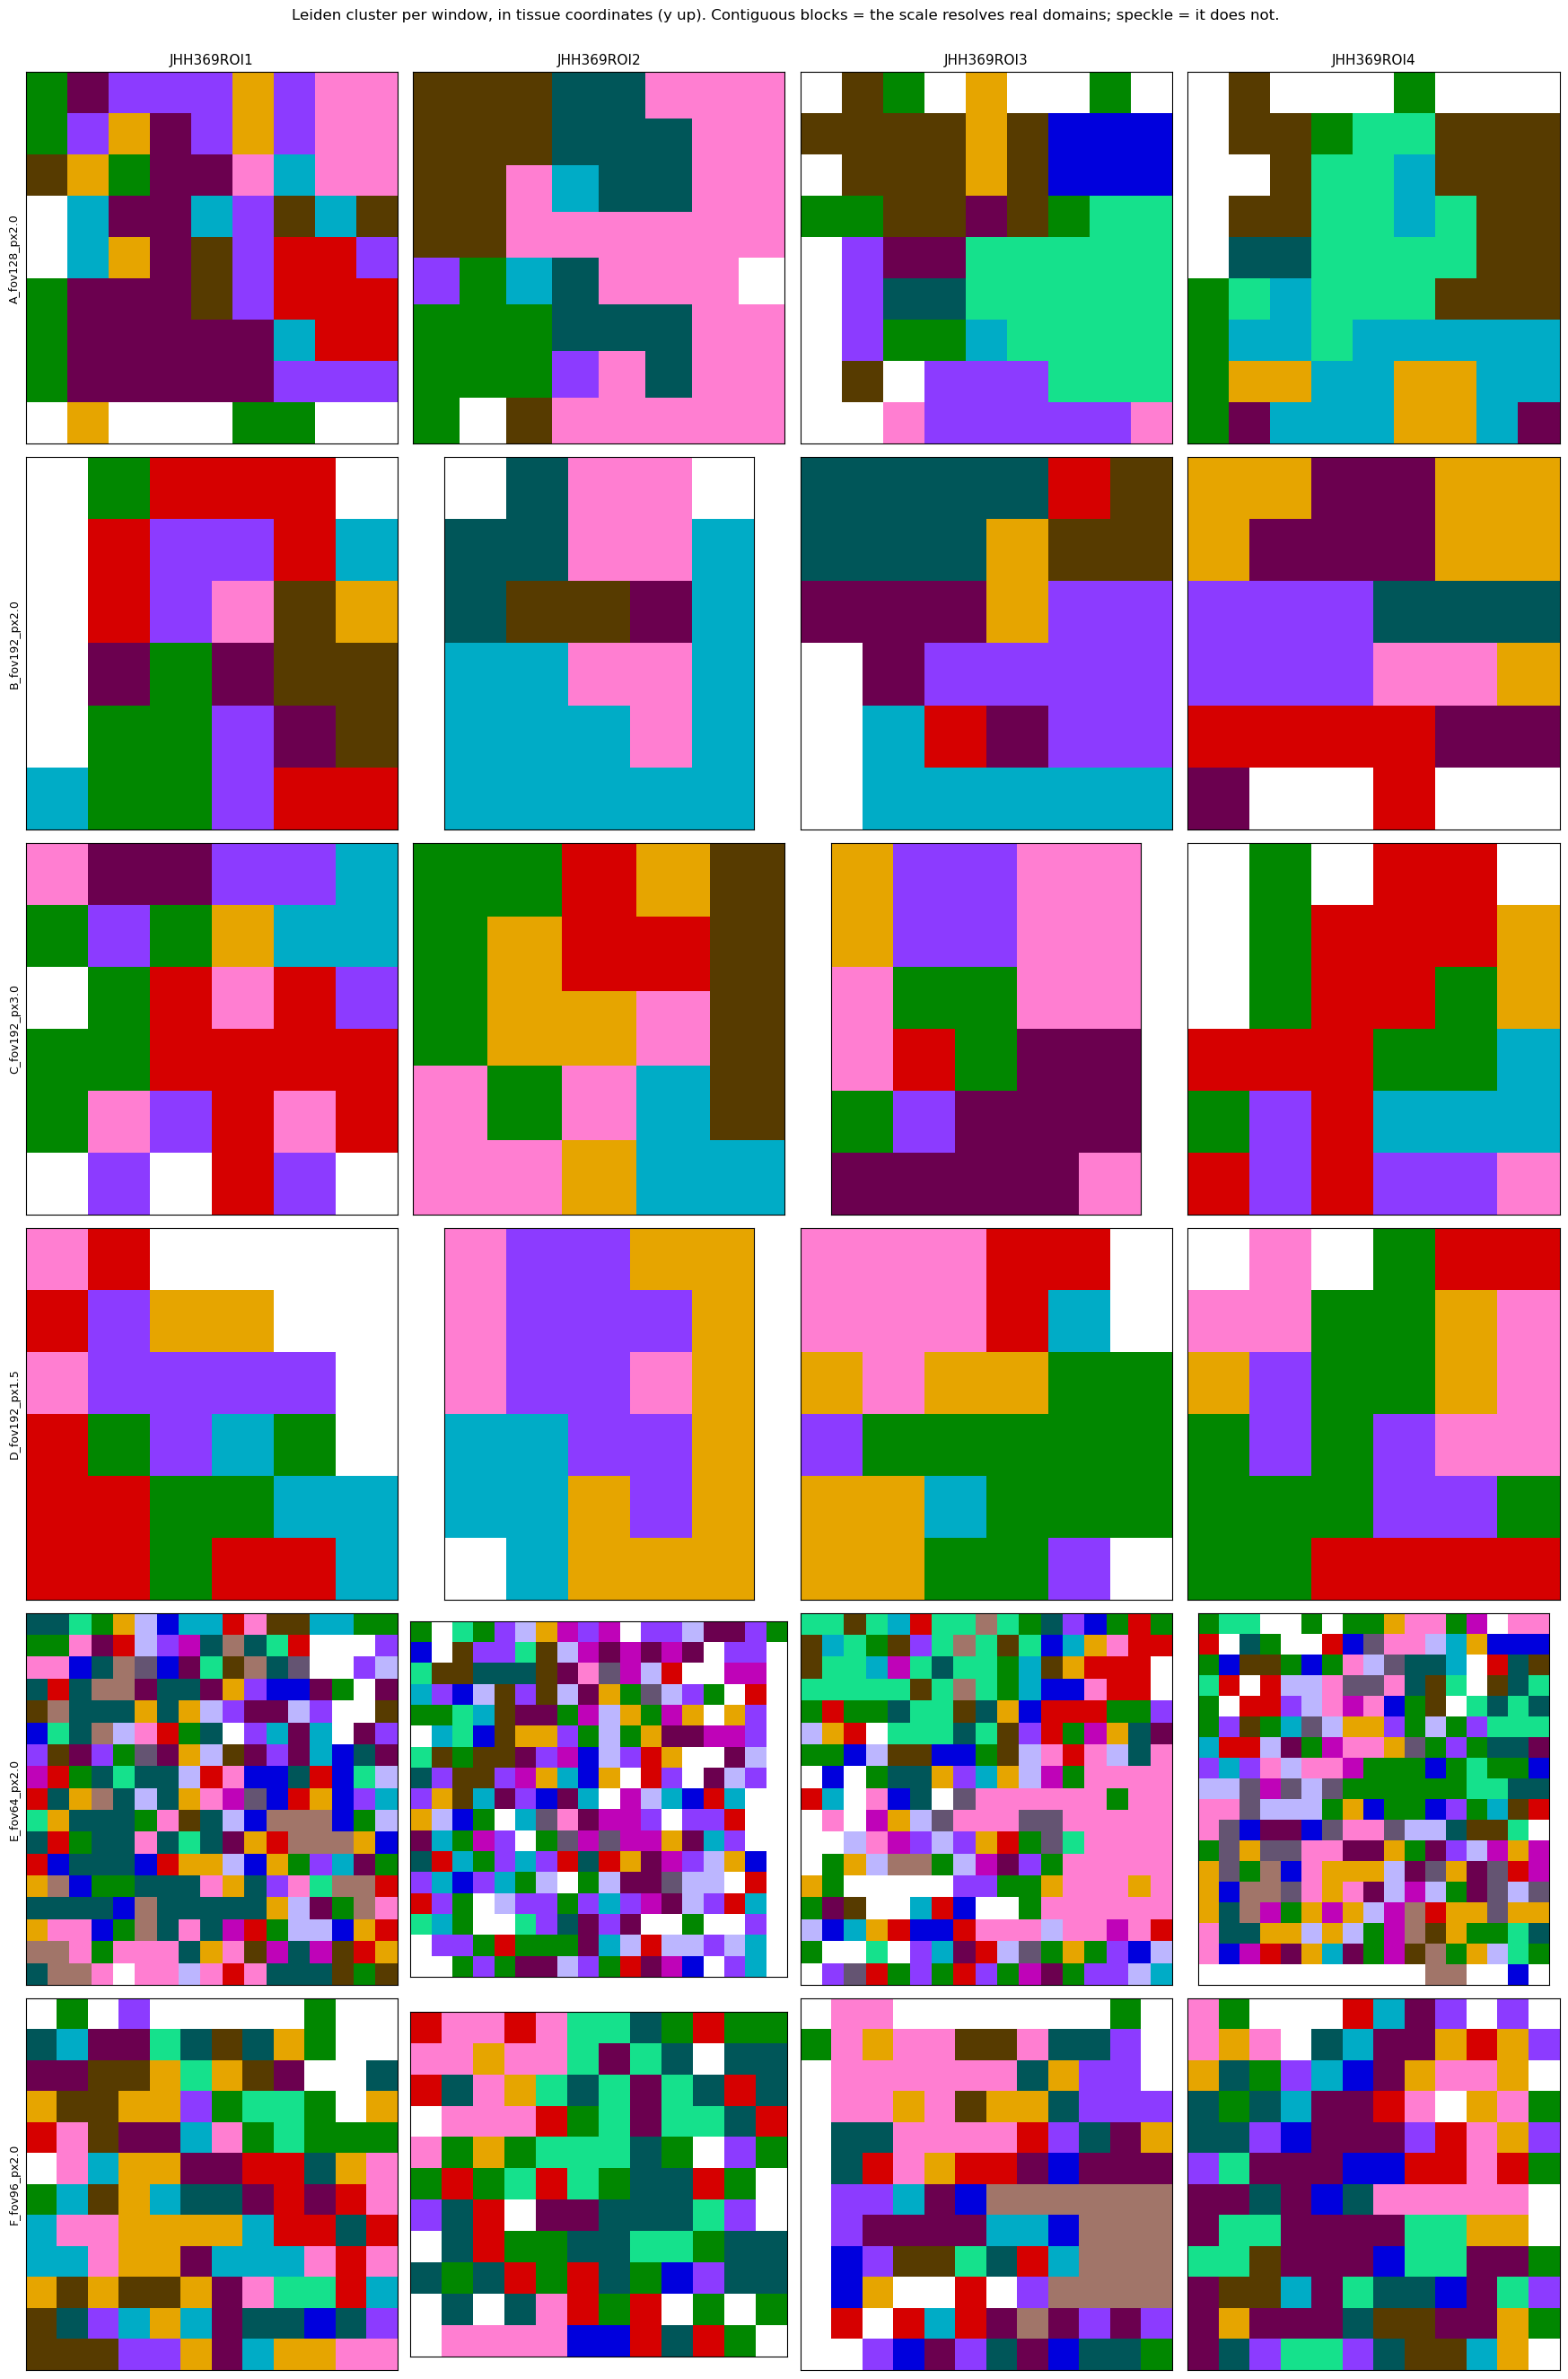

In [11]:
if results:
    ROIS = sorted(adatas)
    fig, axes = plt.subplots(len(results), len(ROIS), figsize=(4.4 * len(ROIS), 4.4 * len(results)))
    axes = np.atleast_2d(axes)
    for i, name in enumerate(results):
        res, lab = results[name], clusters[name]["labels"]
        for j, roi in enumerate(ROIS):
            m = res["roi"] == roi
            ax = axes[i, j]
            cc = imc_tm.cluster_palette(labels=sorted(np.unique(lab)))
            imc_tm.plot_window_map(ax, res["centers_um"][m], [cc[c] for c in lab[m]],
                                   imc_tm.sweep_spec(name)["fov_um"])
            ax.set_xticks([]); ax.set_yticks([])
            if i == 0: ax.set_title(roi, fontsize=11)
            if j == 0: ax.set_ylabel(name, fontsize=9)
    plt.suptitle("Leiden cluster per window, in tissue coordinates (y up). "
                 "Contiguous blocks = the scale resolves real domains; speckle = it does not.",
                 y=1.002, fontsize=12)
    plt.tight_layout()

### Metric summary

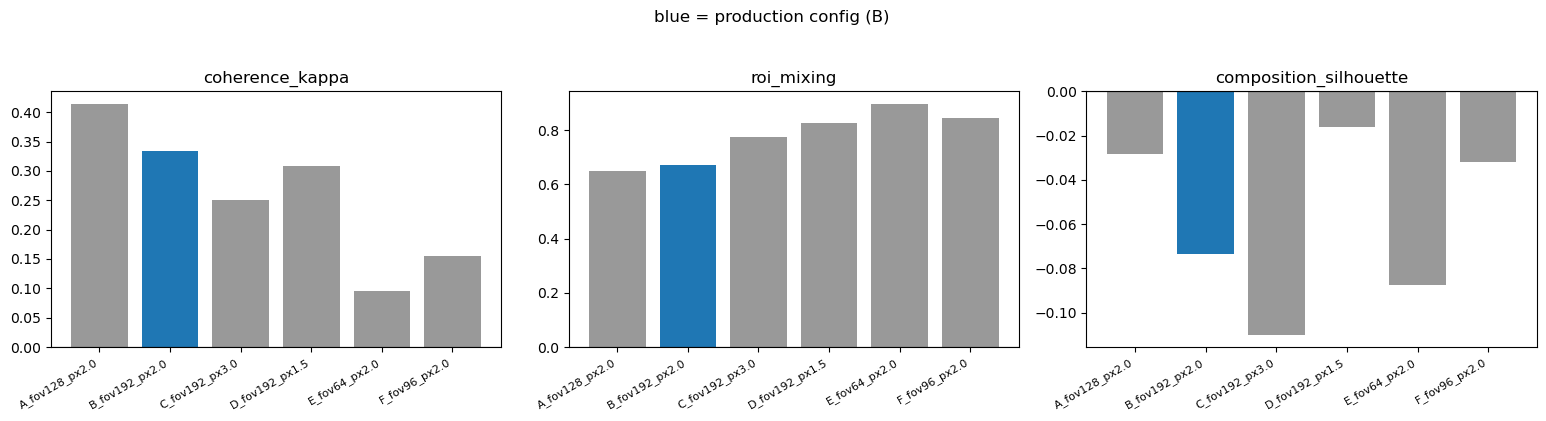

In [12]:
if met is not None:
    show_cols = ["coherence_kappa", "roi_mixing", "composition_silhouette"]
    fig, axes = plt.subplots(1, len(show_cols), figsize=(5.2 * len(show_cols), 4))
    for ax, c in zip(axes, show_cols):
        v = met[c]
        ax.bar(range(len(v)), v.values,
               color=["C0" if n.startswith("B") else "0.6" for n in v.index])
        ax.set_xticks(range(len(v))); ax.set_xticklabels(v.index, rotation=30, ha="right", fontsize=8)
        ax.set_title(c); ax.axhline(0, color="k", lw=0.8)
    plt.suptitle("blue = production config (B)", y=1.04)
    plt.tight_layout()

## How to read this

Pick the config that maximises **`kappa_norm`** (kappa over its own geometric
ceiling — raw `coherence_kappa` still favours small FOV) *without* collapsing
**`roi_mixing`**, and read **`composition_silhouette`** as context rather than as a
target. Coherence measures whether the embedding found real spatial structure; ROI
mixing is the guard against it having found batch. A config that wins on coherence
while ROI mixing falls far below its null has memorised the four ROIs and should be
rejected.

Caveats worth carrying forward:

- **This is a screen.** 6,400 steps per config. The ranking should be robust because
  the schedule is identical; absolute quality is not. Re-train the winner properly
  before drawing biological conclusions.
- **One patient.** JHH369 only. Whatever wins here should be confirmed on the full
  48-ROI cohort before it becomes the production setting.
- **Window counts differ by 9×** — 1078 at 64 µm down to 118 at 192 µm. The
  FOV-scaled filter equalises *tissue coverage* (every config retains 26–28k cells,
  an 8% spread), which is what makes the embeddings comparable, but it cannot
  equalise count: a smaller window tiles the same tissue more times. This is why
  `coherence_kappa` and not the z-score is the ranking metric — see above. Cluster
  stability still rests on fewer points at 192 µm.
- **Border share is improved but not equal** — 13.6 / 26.8 / 15.3 / 28.2 / 16.9 /
  19.4 % for A–F under the scaled filter, against 32–51% under the old fixed one.
  It is no longer FOV-monotone, but the ~2× residual spread at 192 µm still favours
  the 192 µm configs slightly on coherence, since a border ring is contiguous by
  construction.
- If the answer is close between two configs, prefer the **cheaper** one — C is 0.44×
  the compute of B for the same 192 µm field of view.